In [ ]:
import torch 
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

import core_neural_network_components.cnn_nature_classifier.helper_utils as helper_utils

In [3]:
# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [4]:
cifar100_mean = (0.5071, 0.4867, 0.4408)
cifar100_std = (0.2675, 0.2565, 0.2761)

In [5]:
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(cifar100_mean, cifar100_std)
])

val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(cifar100_mean, cifar100_std)
])

In [6]:
subset_target_classes = [
    # Flowers
    'orchid', 'poppy', 'sunflower',
    # Mammals
    'fox', 'raccoon', 'skunk',
    # Insects
    'butterfly', 'caterpillar', 'cockroach'
]

In [7]:
# Call the helper function to prepare the datasets
train_dataset_proto, val_dataset_proto = helper_utils.load_cifar100_subset(subset_target_classes, train_transform, val_transform)

Dataset found in './cifar_100'. Loading from local files.
Files already downloaded and verified


d:\workspace\pytorch-for-dl\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Files already downloaded and verified
Dataset loaded successfully.

Filtering for 9 classes...
Filtering complete. Returning training and validation datasets.


In [8]:
# Set the number of samples to be processed in each batch
batch_size = 64

# Create a data loader for the training set, with shuffling enabled
train_loader_proto = DataLoader(train_dataset_proto, batch_size=batch_size, shuffle=True)

# Create a data loader for the validation set, without shuffling
val_loader_proto = DataLoader(val_dataset_proto, batch_size=batch_size, shuffle=False)

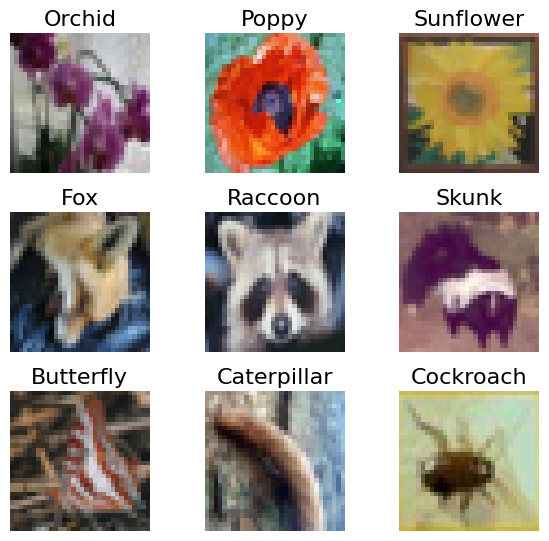

In [9]:
# Visualize a 3x3 grid of random training images
helper_utils.visualise_images(train_dataset_proto, grid=(3, 3))

In [ ]:
class SimpleCNN(nn.Module):

    def __init__(self, num_classes):
        super(SimpleCNN, self).__init__()

        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.relu3 = nn.ReLU()
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.flatten = nn.Flatten()

        self.fc1 = nn.Linear(128*4*4, 512)
        self.relu4 = nn.ReLU()
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(512, num_classes)


    def forward(self, x):
        """
        Defines the forward pass of the model.

        Args:
            x: The input tensor of shape (batch_size, channels, height, width).

        Returns:
            The output tensor containing the logits for each class.
        """
        # Pass input through the first convolutional block
        x = self.conv1(x)
        x = self.relu1(x)
        x = self.pool1(x)

        # Pass feature maps through the second convolutional block
        x = self.conv2(x)
        x = self.relu2(x)
        x = self.pool2(x)
        
        # Pass feature maps through the third convolutional block
        x = self.conv3(x)
        x = self.relu3(x)
        x = self.pool3(x)

        # Flatten the output for the fully connected layers
        x = self.flatten(x)

        # Pass the flattened features through the fully connected layers
        x = self.fc1(x)
        x = self.relu4(x) 
        x = self.dropout(x)
        x = self.fc2(x)

        # Return the final output logits
        return x

In [30]:
num_classes = len(train_dataset_proto.classes)

prototype_model = SimpleCNN(num_classes)

In [31]:
def print_data_flow(model):
    """
    Prints the shape of a tensor as it flows through each layer of the model.

    Args:
        model: An instance of the PyTorch model to inspect.
    """
    # Create a sample input tensor (batch_size, channels, height, width)
    x = torch.randn(1, 3, 32, 32)

    # Track the tensor shape at each stage
    print(f"Input shape: \t\t{x.shape}")

    # First conv block
    x = model.conv1(x)
    print(f"After conv1: \t\t{x.shape}")
    x = model.relu1(x)
    x = model.pool1(x)
    print(f"After pool1: \t\t{x.shape}")

    # Second conv block
    x = model.conv2(x)
    print(f"After conv2: \t\t{x.shape}")
    x = model.relu2(x)
    x = model.pool2(x)
    print(f"After pool2: \t\t{x.shape}")

    # Third conv block
    x = model.conv3(x)
    print(f"After conv3: \t\t{x.shape}")
    x = model.relu3(x)
    x = model.pool3(x)
    print(f"After pool3: \t\t{x.shape}")

    # Flatten using the model's flatten layer
    x = model.flatten(x)
    print(f"After flatten: \t\t{x.shape}")

    # Fully connected layers
    x = model.fc1(x)
    print(f"After fc1: \t\t{x.shape}")
    x = model.relu4(x)
    x = model.dropout(x)
    x = model.fc2(x)
    print(f"Output shape (fc2): \t{x.shape}")

In [32]:
# Print the model's architecture
print(prototype_model)

# Call the helper function to visualize the data flow
print("\n--- Tracing Data Flow ---")
print_data_flow(prototype_model)

SimpleCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu3): ReLU()
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=2048, out_features=512, bias=True)
  (relu4): ReLU()
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=512, out_features=9, bias=True)
)

--- Tracing Data Flow ---
Input shape: 		torch.Size([1, 3, 32, 32])
After conv1: 		torch.Size([1, 32, 32, 32])
After pool1: 		torch.Size([1, 32, 16, 16])
After conv2: 		torch.Size([1, 64, 16, 16])
After pool2: 		t

In [21]:
loss_function = nn.CrossEntropyLoss()

optimizer_prototype = optim.Adam(prototype_model.parameters(), lr = 0.001)

In [22]:
def training_loop(model, train_loader, val_loader, loss_function, optimizer, num_epochs, device):

    model.to(device)

    # Initialize lists to store training and validation metrics
    train_losses = []
    val_losses = []
    val_accuracies = []
    
    # Print a message indicating the start of the training process
    print("--- Training Started ---")
    
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = loss_function(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)

        # Calculate the average training loss for the epoch
        epoch_loss = running_loss / len(train_loader.dataset)
        # Append the epoch loss to the list of training losses
        train_losses.append(epoch_loss)
        
        # Set the model to evaluation mode
        model.eval()
        # Initialize running validation loss and correct predictions count
        running_val_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)

                val_loss = loss_function(outputs, labels)

                # Accumulate the validation loss
                running_val_loss += val_loss.item() * images.size(0)
                
                # Get the predicted class labels
                _, predicted = torch.max(outputs, 1)
                # Update the total number of samples
                total += labels.size(0)
                # Update the number of correct predictions
                correct += (predicted == labels).sum().item()

         # Calculate the average validation loss for the epoch
        epoch_val_loss = running_val_loss / len(val_loader.dataset)
        # Append the epoch validation loss to the list
        val_losses.append(epoch_val_loss)
        
        # Calculate the validation accuracy for the epoch
        epoch_accuracy = 100.0 * correct / total
        # Append the epoch accuracy to the list
        val_accuracies.append(epoch_accuracy)
        
        # Print the metrics for the current epoch
        print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {epoch_loss:.4f}, Val Loss: {epoch_val_loss:.4f}, Val Accuracy: {epoch_accuracy:.2f}%")
        
    # Print a message indicating the end of the training process
    print("--- Finished Training ---")
    
    # Consolidate all metrics into a single list
    metrics = [train_losses, val_losses, val_accuracies]
    
    # Return the trained model and the collected metrics
    return model, metrics

--- Training Started ---
Epoch [1/15], Train Loss: 1.6925, Val Loss: 1.3223, Val Accuracy: 52.78%
Epoch [2/15], Train Loss: 1.2926, Val Loss: 1.1131, Val Accuracy: 61.33%
Epoch [3/15], Train Loss: 1.0766, Val Loss: 1.0797, Val Accuracy: 61.56%
Epoch [4/15], Train Loss: 0.9626, Val Loss: 0.8908, Val Accuracy: 70.56%
Epoch [5/15], Train Loss: 0.9118, Val Loss: 0.8902, Val Accuracy: 70.00%
Epoch [6/15], Train Loss: 0.8534, Val Loss: 0.8169, Val Accuracy: 74.44%
Epoch [7/15], Train Loss: 0.7960, Val Loss: 0.8032, Val Accuracy: 74.22%
Epoch [8/15], Train Loss: 0.7387, Val Loss: 0.7944, Val Accuracy: 73.11%
Epoch [9/15], Train Loss: 0.6923, Val Loss: 0.7304, Val Accuracy: 75.44%
Epoch [10/15], Train Loss: 0.6619, Val Loss: 0.6920, Val Accuracy: 76.78%
Epoch [11/15], Train Loss: 0.6204, Val Loss: 0.7055, Val Accuracy: 77.00%
Epoch [12/15], Train Loss: 0.5800, Val Loss: 0.7102, Val Accuracy: 77.11%
Epoch [13/15], Train Loss: 0.5466, Val Loss: 0.6430, Val Accuracy: 79.33%
Epoch [14/15], Train L

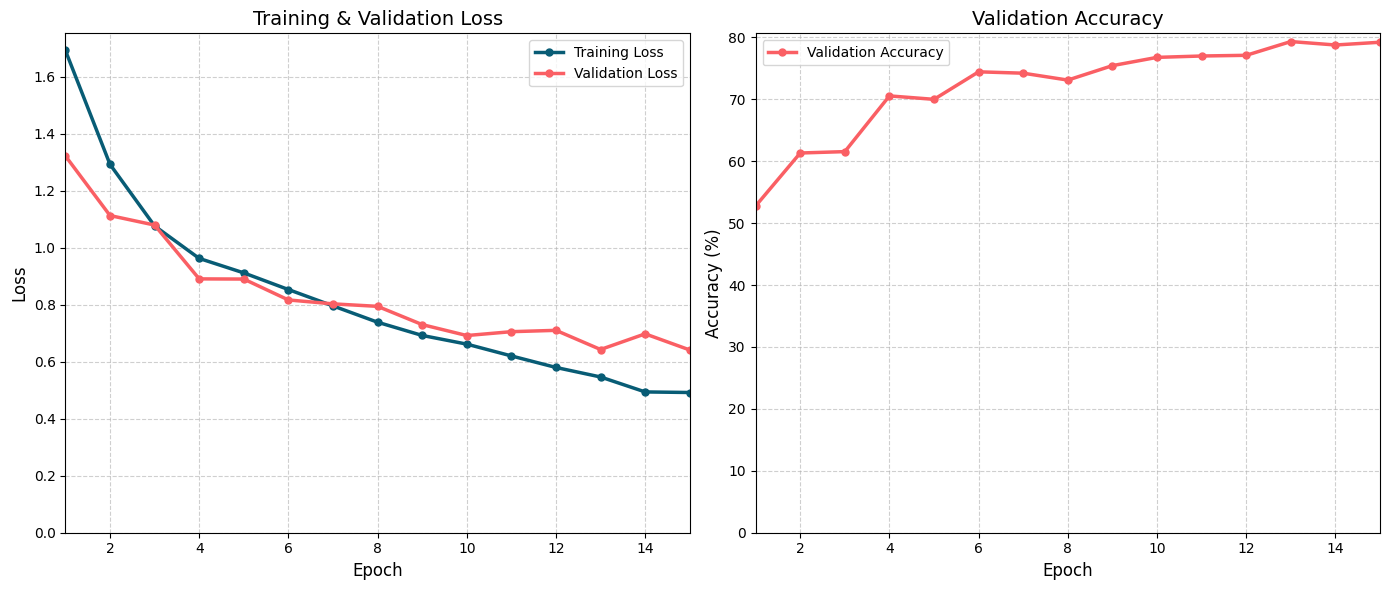

In [23]:
# Start the training process by calling the training loop function
trained_proto_model, training_metrics_proto = training_loop(
    model=prototype_model, 
    train_loader=train_loader_proto, 
    val_loader=val_loader_proto, 
    loss_function=loss_function, 
    optimizer=optimizer_prototype, 
    num_epochs=15, 
    device=device
)

# Visualize the training metrics (loss and accuracy)
print("\n--- Training Plots ---\n")
helper_utils.plot_training_metrics(training_metrics_proto)

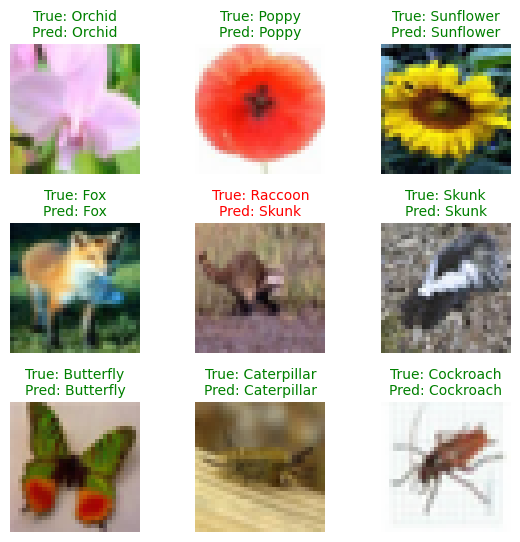

In [24]:
# Visualize model predictions on a sample of validation images
helper_utils.visualise_predictions(
    model=trained_proto_model, 
    data_loader=val_loader_proto, 
    device=device, 
    grid=(3, 3)
)

### Scaling Up: Training the Full Model

In [25]:
# Define the full class list.
all_target_classes = [
    # Flowers
    'orchid', 'poppy', 'rose', 'sunflower', 'tulip',
    # Mammals
    'fox', 'porcupine', 'possum', 'raccoon', 'skunk',
    # Insects
    'bee', 'beetle', 'butterfly', 'caterpillar', 'cockroach'
]

# Load the full datasets.
train_dataset, val_dataset = helper_utils.load_cifar100_subset(all_target_classes, train_transform, val_transform)

Dataset found in './cifar_100'. Loading from local files.
Files already downloaded and verified


d:\workspace\pytorch-for-dl\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Files already downloaded and verified
Dataset loaded successfully.

Filtering for 15 classes...
Filtering complete. Returning training and validation datasets.


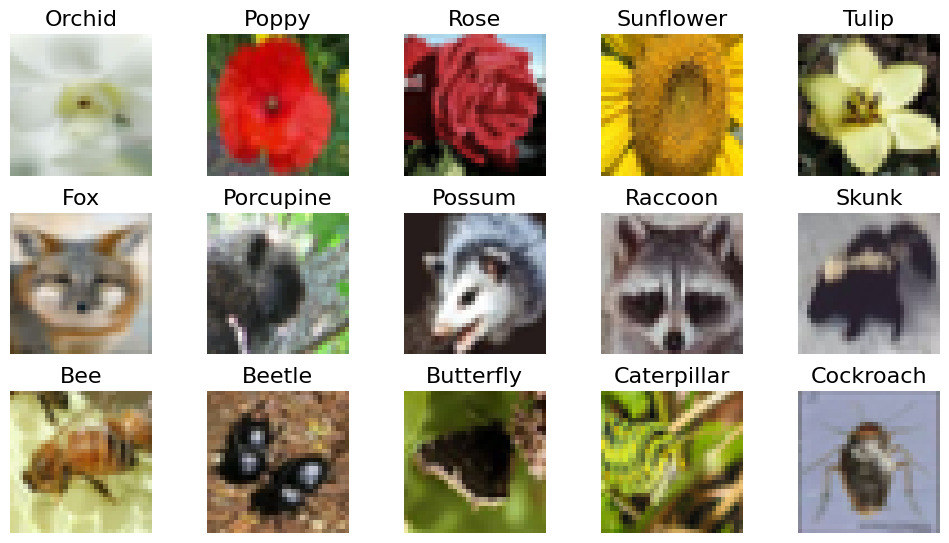

In [26]:
# Create a data loader for the training set, with shuffling enabled
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# Create a data loader for the validation set, without shuffling
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# Visualize a 3x5 grid of random training images
helper_utils.visualise_images(train_dataset, grid=(3, 5))

In [33]:
# Get the number of classes
num_classes = len(train_dataset.classes)

# Instantiate the full model
model = SimpleCNN(num_classes)

# Print the model's architecture (notice, it now has 15 output classes)
print(model)

SimpleCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu3): ReLU()
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=2048, out_features=512, bias=True)
  (relu4): ReLU()
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=512, out_features=15, bias=True)
)


--- Training Started ---
Epoch [1/25], Train Loss: 2.1680, Val Loss: 1.8300, Val Accuracy: 37.40%
Epoch [2/25], Train Loss: 1.7856, Val Loss: 1.6029, Val Accuracy: 45.13%
Epoch [3/25], Train Loss: 1.6340, Val Loss: 1.4830, Val Accuracy: 48.33%
Epoch [4/25], Train Loss: 1.5354, Val Loss: 1.4557, Val Accuracy: 51.47%
Epoch [5/25], Train Loss: 1.4284, Val Loss: 1.2918, Val Accuracy: 55.80%
Epoch [6/25], Train Loss: 1.3558, Val Loss: 1.2748, Val Accuracy: 58.33%
Epoch [7/25], Train Loss: 1.2898, Val Loss: 1.2229, Val Accuracy: 60.60%
Epoch [8/25], Train Loss: 1.2286, Val Loss: 1.2118, Val Accuracy: 59.13%
Epoch [9/25], Train Loss: 1.1802, Val Loss: 1.1956, Val Accuracy: 60.53%
Epoch [10/25], Train Loss: 1.1136, Val Loss: 1.1888, Val Accuracy: 60.73%
Epoch [11/25], Train Loss: 1.0568, Val Loss: 1.1078, Val Accuracy: 62.87%
Epoch [12/25], Train Loss: 1.0170, Val Loss: 1.1152, Val Accuracy: 64.00%
Epoch [13/25], Train Loss: 0.9848, Val Loss: 1.1081, Val Accuracy: 64.20%
Epoch [14/25], Train L

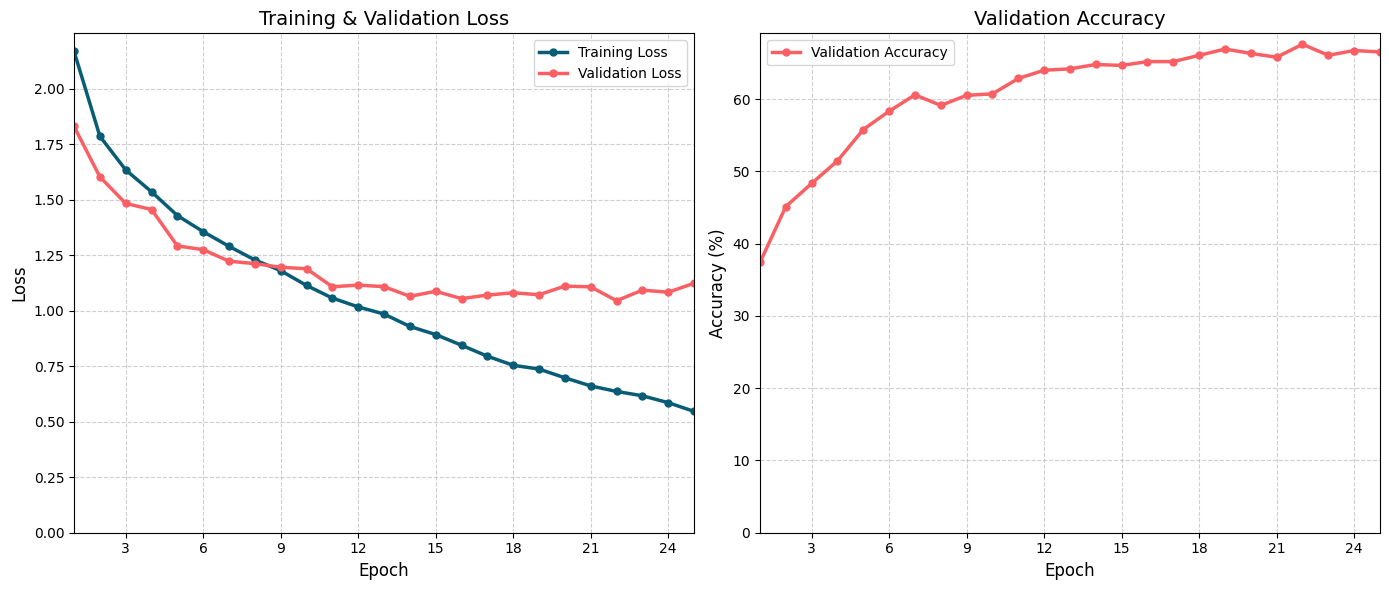

In [34]:
# Optimizer for the full model
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Start the training process for the full model on all 15 classes
trained_model, training_metrics = training_loop(
    model=model, 
    train_loader=train_loader, 
    val_loader=val_loader, 
    loss_function=loss_function, 
    optimizer=optimizer, 
    num_epochs=25, 
    device=device
)

# Visualize the training metrics for the full model
print("\n--- Training Plots ---\n")
helper_utils.plot_training_metrics(training_metrics)

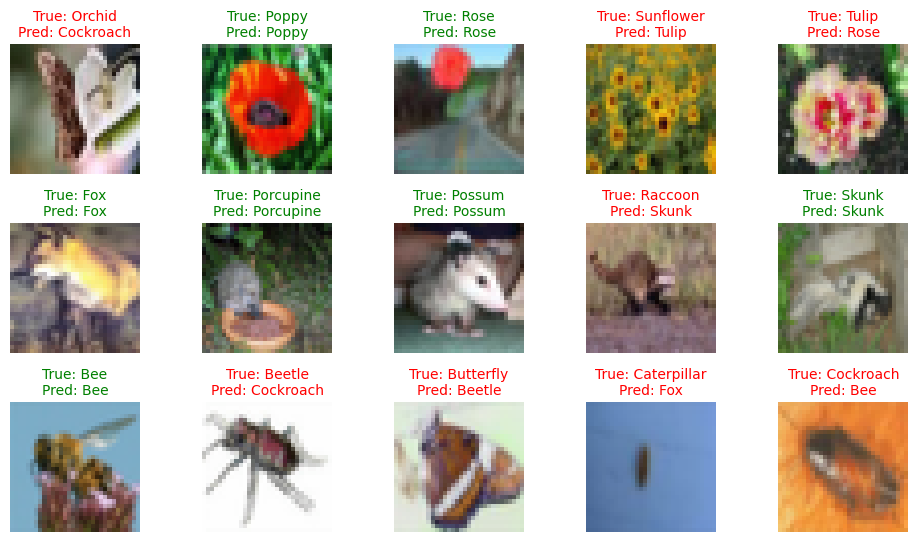

In [35]:
### Optional: Uncomment and run this cell to see the predictions made by the full model

helper_utils.visualise_predictions(
    model=trained_model, 
    data_loader=val_loader, 
    device=device, 
    grid=(3, 5)
)